# Decision Tree Regression
##### Owen Lindsey
##### Professor Majumdar
##### AIT-110: Statistical Learning Theory
##### Grand Canyon University
##### Date: 
##### Video Link: 

# Understanding Decision Trees and Random Forests

## 1. Building a Decision Tree

***Tree Structure*** -- Decision Trees are comprised of a ***root node***, ***intermediate nodes***, and ***leaf nodes***. These trees may look abnormal, due to the root being the top most node, with the rest of the nodes following BELOW and splitting based on deterministic outcomes.

***Choosing Splits*** -- The algorithm works by evaluating all possible splits across all features to find the best one. For each feature, it tests different threshold values and calculates the resulting purity of the child nodes. The split that produces the greatest improvement in purity (or reduction in impurity) is chosen.

***Measuring Purity*** -- For classification, the Gini Index measures impurity, where values closer to 0 indicate purer nodes (0 is completely pure). Information Gain measures how much information was gained by splitting at a specific location. For regression trees, we use variance reduction or MSE (Mean Squared Error) to measure split quality - choosing splits that minimize the variance within each child node.

***Pruning*** -- To prevent overfitting, trees can be pruned using two approaches:
- **Pre-pruning**: Stop growing the tree early by setting constraints (max depth, minimum samples per leaf, minimum impurity decrease)
- **Post-pruning**: Grow a full tree, then remove branches that don't improve performance on validation data using cost-complexity pruning (alpha parameter)

## 2. Limitations of Decision Trees

Decision trees have several key limitations:
- **High Variance**: Small changes in data can result in completely different tree structures, making them unstable
- **Overfitting**: Trees can grow too complex and memorize training data rather than learning generalizable patterns
- **Greedy Algorithm**: Trees make locally optimal decisions at each split, which may not lead to the globally optimal tree
- **Difficulty with Linear Relationships**: Trees struggle to model simple linear relationships efficiently

***How Random Forests Address These*** -- Random Forests tackle these limitations by combining multiple trees trained on different subsets of data with random feature selection. This ensemble approach reduces variance and overfitting while maintaining predictive power.

## 3. Random Forest Algorithm

***Combining Multiple Trees*** -- Random Forests improve model performance by creating an ensemble of decision trees and aggregating their predictions. For regression, predictions are averaged; for classification, the majority vote is used.

***Bootstrapping (Bagging)*** -- Each tree is trained on a bootstrapped sample of the original dataset. This means randomly sampling the data with replacement, so each tree sees a slightly different version of the data (typically ~63% unique samples, with some repeated).

***Random Feature Selection*** -- At each split in each tree, only a random subset of features is considered (typically √p for classification or p/3 for regression, where p is the total number of features). This decorrelates the trees, preventing them from all making the same mistakes.

## 4. Variance Reduction

***How It Works*** -- By averaging predictions across many trees, Random Forests significantly reduce variance compared to a single decision tree. Each individual tree may overfit to its particular bootstrap sample, but these overfitting patterns are different across trees. When averaged, the overfitting cancels out while the true signal remains.

***Benefits for Accuracy*** -- Lower variance means the model generalizes better to unseen data. While individual trees have low bias but high variance, Random Forests maintain that low bias while achieving much lower variance. This leads to more stable predictions and better performance on test data.

## 5. Variable Importance

***Measuring Importance*** -- Random Forests provide two main metrics for variable importance:

1. **Mean Decrease in Impurity (MDI)**: Measures how much each feature decreases the weighted impurity (Gini or MSE) across all trees. Features that create larger decreases in impurity are more important.

2. **Permutation Importance**: Measures how much the model's accuracy decreases when a feature's values are randomly shuffled. Features that cause larger drops in accuracy when permuted are more important.

***Interpretation and Use*** -- Variable importance scores help identify which features contribute most to predictions. This is useful for:
- Feature selection (removing unimportant features)
- Understanding the underlying relationships in the data
- Communicating model insights to stakeholders
- Debugging model behavior 



# 2. Building Decision Trees and Random Forests



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38444 entries, 0 to 38443
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         38444 non-null  int64  
 1   Age                38444 non-null  int64  
 2   Gender             38444 non-null  object 
 3   Country            38444 non-null  object 
 4   Income             38444 non-null  int64  
 5   ProductQuality     38444 non-null  int64  
 6   ServiceQuality     38444 non-null  int64  
 7   PurchaseFrequency  38444 non-null  int64  
 8   FeedbackScore      38444 non-null  object 
 9   LoyaltyLevel       38444 non-null  object 
 10  SatisfactionScore  38444 non-null  float64
dtypes: float64(1), int64(6), object(4)
memory usage: 3.2+ MB


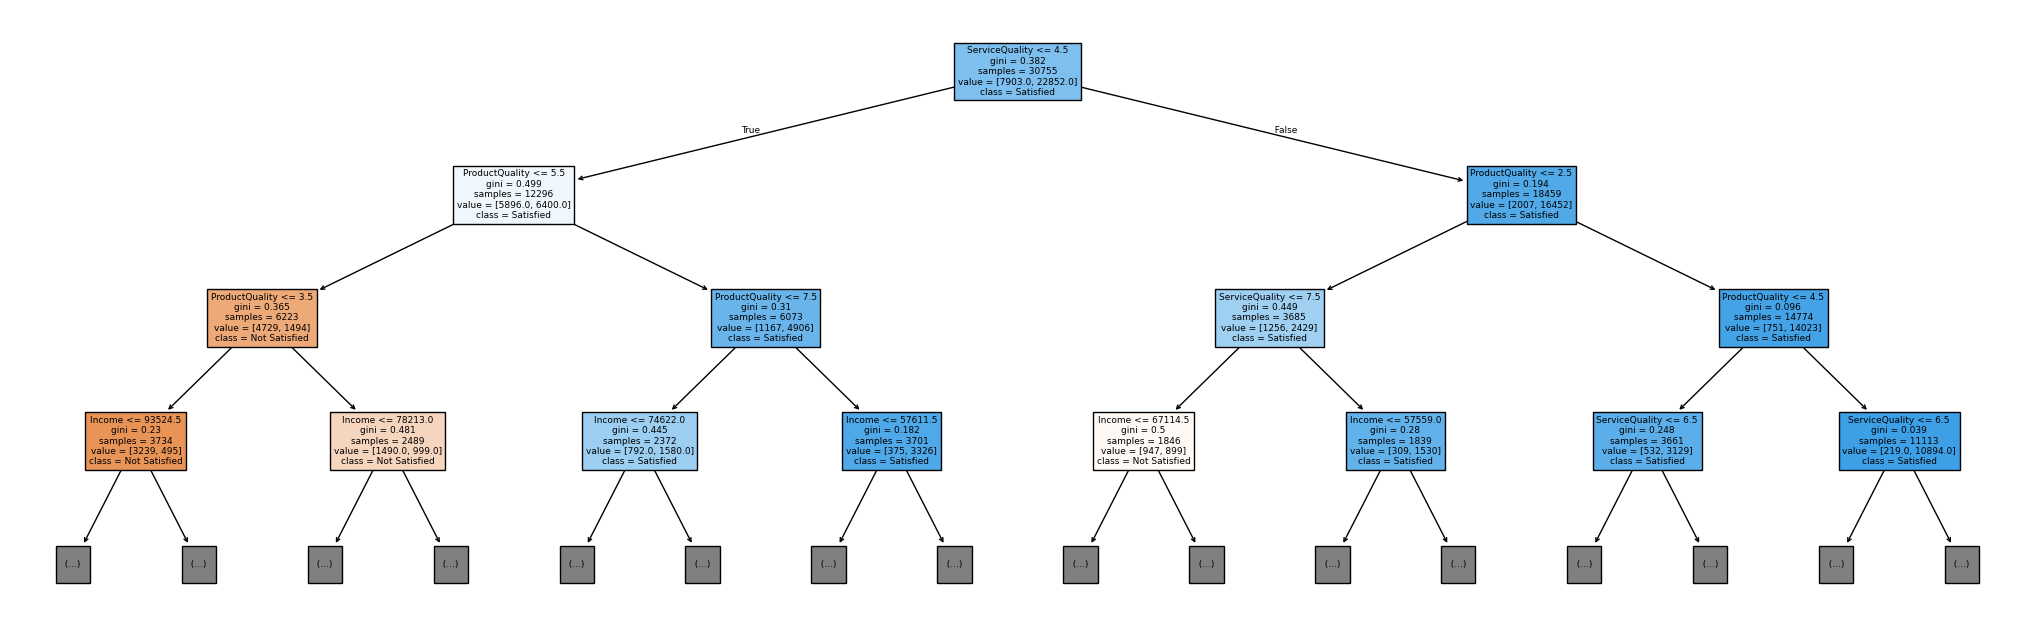

In [18]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import *
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error




from IPython.display import Image, display_svg, SVG
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import pandas as pd
import numpy as np
%matplotlib inline

customer_data = pd.read_csv('data/customer_feedback_satisfaction.csv')

customer_data.head()

customer_data.info()

feedback_map = {'Low': 0, 'Medium': 1, 'High': 2}
loyalty_map = {'Bronze': 0, 'Silver': 1, 'Gold': 2}

customer_data['FeedbackScore'] = customer_data['FeedbackScore'].map(feedback_map)
customer_data['LoyaltyLevel'] = customer_data['LoyaltyLevel'].map(loyalty_map)
customer_data['Gender'] = customer_data['Gender'].map({'Male': 0, 'Female': 1})
customer_data['Country'] = customer_data['Country'].map({'United States': 0, 'Canada': 1, 'Mexico': 2, 'Other': 3})
customer_data['Satisfied'] = (customer_data['SatisfactionScore'] >= 75).astype(int)



X_train, X_test, y_train, y_test = train_test_split(
    customer_data[['Age','Gender','Country','Income','ProductQuality','ServiceQuality','PurchaseFrequency','FeedbackScore','LoyaltyLevel']],
    customer_data['Satisfied'],
    test_size=0.2,
    random_state=42
)

dt_classifier = DecisionTreeClassifier()

dt_classifier.fit(X_train, y_train)

plt.figure(figsize=(26,8))
plot_tree(dt_classifier, filled=True, feature_names=X_train.columns, class_names=['Not Satisfied', 'Satisfied'], max_depth=3)
plt.show()


In [ ]:
tree = DecisionTreeClassifier(random_state=42)

path = tree.cost_complexity_pruning_path(X_train, y_train)
effective_alphas = path.ccp_alphas
impurities = path.impurities

count_leaves = lambda tree: sum(tree.tree_.children_left[i] == tree.tree_.children_right[i] == -1 for i in range(tree.tree_.node_count))

leaf_counts = [count_leaves(DecisionTreeClassifier(random_state=0, ccp_alpha=alpha).fit(X_train, y_train)) for alpha in effective_alphas]

pruning_results = pd.DataFrame({
    'alpha': effective_alphas,
    'impurity': impurities,
    'leaves': leaf_counts,
    'cost function': [f"{imp:.3f} + {leaves}α" for imp, leaves in zip(impurities, leaf_counts)]
})

print(pruning_results)

dt_pruned = DecisionTreeClassifier(random_state=42, ccp_alpha=0.0001637)

dt_pruned.fit(X_train, y_train)

plt.figure(figsize=(26,8))
plot_tree(dt_pruned, filled=True, feature_names=X_train.columns, class_names=['Not Satisfied', 'Satisfied'], max_depth=3)
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

scores = []
for alpha in effective_alphas[::20]:  # sample every 20th to keep it fast
    dt = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    cv_score = cross_val_score(dt, X_train, y_train, cv=5, scoring='accuracy').mean()
    scores.append((alpha, cv_score))

best_alpha, best_score = max(scores, key=lambda x: x[1])
print(f"Best alpha: {best_alpha}, CV Accuracy: {best_score:.4f}")

Best alpha: 0.00016378423047049874, CV Accuracy: 0.8798


# The Results

### Interpreting the First Three Splits

The unpruned decision tree reveals the features the model prioritizes most when predicting customer satisfaction:

- **Split 1 (Root): ServiceQuality <= 4.5** — The model considers service quality the single most important factor. Customers are first divided into those with low service ratings (left) vs. higher service ratings (right).
- **Split 2: ProductQuality <= 5.5 / ProductQuality <= 2.5** — On both branches, the model next evaluates product quality, confirming it as the second most decisive feature. Thresholds differ by branch since the populations have different distributions.
- **Split 3: Income, ProductQuality, and ServiceQuality** — The third level refines predictions further using income and additional product/service quality thresholds. Notably, income appears as a factor for the first time here, suggesting it plays a secondary role compared to quality metrics.

The tree shows that **ServiceQuality** and **ProductQuality** are the primary drivers of customer satisfaction, while demographic factors like Age, Gender, and Country play a lesser role in the initial splits.

### Pruning

Cost-complexity pruning was applied using `ccp_alpha=0.0001637`, selected via 5-fold cross-validation achieving a CV accuracy of ~88%. The pruning path was computed across 1545 alpha values, showing the trade-off between tree complexity (number of leaves) and impurity. The chosen alpha reduces the tree from 3632 leaves to a much simpler structure while preserving the key decision boundaries. This prevents overfitting — the unpruned tree memorizes the training data, while the pruned tree generalizes better to unseen data.

# Random Forest

# Random Forest Results

## Model Performance

The baseline Random Forest (100 trees, default parameters) achieved:
- **Accuracy:** 88.8%
- **Log Loss:** 0.259

After hyperparameter tuning via `GridSearchCV` (5-fold cross-validation), the optimal parameters were found to be:
- **n_estimators:** 100
- **max_depth:** 10
- **min_samples_split:** 5

The tuned model improved performance slightly:
- **Accuracy:** 89.1%
- **Log Loss:** 0.252

The ensemble accuracy calculation (using the binomial distribution with 100 trees each at 80% individual accuracy) yields ~99.99%, demonstrating the theoretical power of majority voting in ensemble methods — even weak learners become highly accurate when combined.

## Decision Tree vs. Random Forest

| Metric | Decision Tree (Pruned) | Random Forest (Tuned) |
|--------|----------------------|----------------------|
| CV Accuracy | ~88% | ~89.1% |
| Log Loss | — | 0.252 |

The Random Forest outperforms the pruned decision tree, though the margin is modest (~1%). This is expected: the Random Forest reduces variance by averaging predictions across 100 decorrelated trees, each trained on bootstrapped samples with random feature subsets. The single decision tree, even with optimal pruning, remains susceptible to the specific patterns in its training data.

The Random Forest's advantage would likely be more pronounced with noisier data or more complex feature interactions, where a single tree's high variance becomes a larger liability.

## Variable Importance

The feature importance plot from the Random Forest reveals the following hierarchy:

1. **ServiceQuality** — the most important predictor of customer satisfaction, consistent with the decision tree's root split
2. **ProductQuality** — the second most important feature, also consistent with the decision tree's second-level splits
3. **Income** — a moderate contributor, appearing at the third level in the decision tree
4. **PurchaseFrequency, FeedbackScore, LoyaltyLevel** — secondary factors with moderate importance
5. **Age, Gender, Country** — the least important features, suggesting demographic factors play a minimal role in predicting satisfaction

## Business Implications

These results provide actionable insights for the retail company:

- **Invest in service quality first.** It is the single strongest predictor of whether a customer is satisfied. Training customer service representatives, improving response times, and enhancing the overall service experience should be top priorities.
- **Maintain high product quality.** As the second most important factor, ensuring consistent product standards directly impacts satisfaction scores.
- **Income segmentation matters.** Higher-income customers may have different expectations — targeted strategies for different income brackets could improve satisfaction across segments.
- **Demographics are not strong predictors.** Age, gender, and country contribute very little to the model's predictions, suggesting that satisfaction is driven more by experience quality than by who the customer is. Marketing and retention strategies should focus on service and product improvements rather than demographic targeting.

In [47]:

def find_ensemble_accuracy(n,p):
    
    ensemble_accuracy = 0
    for k in range((n + 1) // 2, n + 1):
        ensemble_accuracy += comb(n, k) * (p**k) * ((1-p)**(n-k))
    return ensemble_accuracy

print(f"ensemble accuracy = {find_ensemble_accuracy(100, 0.8)}")

parameters = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [5, 20, 50]
}
clf = GridSearchCV(rf, parameters, scoring='neg_log_loss', cv=5)

clf.fit(X_train, y_train)

print(f"Best parameters: {clf.best_params_}")
print(f"Best log loss: {clf.best_score_}")

rf_best = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=5, random_state=42)
rf_best.fit(X_train, y_train)


print(f"Random Forest log loss = {log_loss(y_test, rf_best.predict_proba(X_test)[:, 1])}")
print(f"Random Forest accuracy = {rf_best.score(X_test, y_test)}")


ensemble accuracy = 0.9999999999948233
Best parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Best log loss: -0.2552840389913851
Random Forest log loss = 0.2521601851199753
Random Forest accuracy = 0.8914033034204708


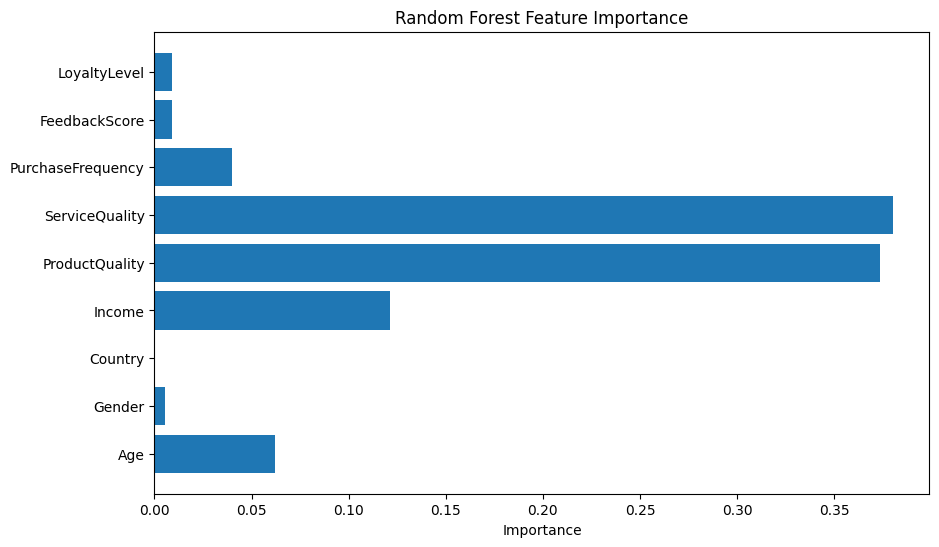

In [48]:
importances = rf_best.feature_importances_
feature_names = X_train.columns

plt.figure(figsize=(10, 6))
plt.barh(feature_names, importances)
plt.xlabel('Importance')
plt.title('Random Forest Feature Importance')
plt.show()